In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
receipts_1 = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/v1/receipts.csv')
receipts_2 = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/v2/receipts.csv')
receipts_1.head()

,user_id,date_operated,category_name,items_count,items_cost
0,70801,2025-06-03,Смартфоны,1.0,10000+
1,70801,2025-06-03,Смартфоны,1.0,10000+
2,95853,2025-06-09,Соки и Сокосодержащие напитки,1.0,100-500
3,90622,2025-07-31,Крупа,1.0,0-100
4,95853,2025-07-17,"Сухие завтраки, мюсли, хлопья",2.0,100-500


In [2]:
accounts= pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/financial_account.csv')
activations = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/offer_activation.csv')
rewards = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/offer_reward.csv')
seens = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/offer_seens.csv')
segments = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/prizm_segments.csv')
clients = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/prod_clients.csv')
tx = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/prod_financial_transaction.csv')
merchants = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/t_merchant.csv')
offers = pd.read_csv('/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1-2/t_offer.csv')
receipts = pd.read_csv("/Users/macbookvera/Desktop/ИИ/Prod_final_indv/data/v1/receipts.csv")


In [15]:

import numpy as np

df_train = seens[['user_id', 'offer_id']].drop_duplicates()
acts = activations[['user_id', 'offer_id', 'activation_date']].drop_duplicates()
df_train = df_train.merge(acts, on=['user_id', 'offer_id'], how='left')
df_train['target'] = df_train['activation_date'].notna().astype(int)
df_train = df_train.drop(columns=['activation_date'])

offers_full = offers.merge(merchants, on='merchant_id_offer', how='left')
df_train = df_train.merge(offers_full[['offer_id', 'brand_dk']], on='offer_id', how='left')


active_accs = accounts[accounts['account_status_cd'] == 'ACT']
acc_features = active_accs.groupby('user_id').agg(
    active_accounts_count=('product_cd', 'count'),      
    unique_products=('product_cd', 'nunique')            
).reset_index()

reward_features = rewards.groupby('user_id').agg(
    total_cashback_sum=('reward_amt', 'sum'),            
    rewards_count=('offer_id', 'count')                  
).reset_index()

tx['is_online'] = (tx['online_transaction_flg'] == 'Y').astype(int)
tx_features = tx.groupby('user_id').agg(
    tx_total_count=('transaction_id', 'count'),
    tx_online_count=('is_online', 'sum')
).reset_index()

user_brand_tx = tx.groupby(['user_id', 'brand_dk']).size().reset_index(name='past_tx_at_brand')

receipts['items_count'] = pd.to_numeric(receipts['items_count'], errors='coerce').fillna(0)
rec_features = receipts.groupby('user_id').agg(
    rec_items_sum=('items_count', 'sum')
).reset_index()

user_profile = clients.merge(segments, on='user_id', how='left')
df_final = df_train.merge(user_profile, on='user_id', how='left')

df_final = df_final.merge(acc_features, on='user_id', how='left')
df_final = df_final.merge(reward_features, on='user_id', how='left')
df_final = df_final.merge(tx_features, on='user_id', how='left')
df_final = df_final.merge(rec_features, on='user_id', how='left')

df_final = df_final.merge(user_brand_tx, on=['user_id', 'brand_dk'], how='left')

num_cols = df_final.select_dtypes(include=['float64', 'int64']).columns
df_final[num_cols] = df_final[num_cols].fillna(0)

df_final['is_existing_client'] = (df_final['past_tx_at_brand'] > 0).astype(int)

df_final.head()

,user_id,offer_id,target,brand_dk,age_bucket,gender_cd,region,last_activity_day,segment,region_size,auto,traveler,entrepreneur,vip_status,active_accounts_count,unique_products,total_cashback_sum,rewards_count,tx_total_count,tx_online_count,rec_items_sum,past_tx_at_brand,is_existing_client
0,76429,961,0,412734.0,15,F,NaN,2026-02-10,t_10 (40),town,0.0,0.0,0.0,not_vip,7.0,3.0,0.0,0.0,160.0,6.0,166.00,0.0,0
1,56744,128,0,399354.0,55,M,МОСКОВСКАЯ ОБЛ,2026-02-10,t_07 (29),town,0.0,0.0,0.0,not_vip,7.0,5.0,0.0,0.0,136.0,13.0,0.00,0.0,0
2,52364,486,0,411399.0,50,F,NaN,2026-02-10,m_05 (11),msk,0.0,0.0,1.0,UPPERMASS,5.0,4.0,0.0,1.0,123.0,2.0,91.79,0.0,0
3,54576,486,0,411399.0,40,F,ВЛАДИМИРСКАЯ ОБЛ,2026-02-10,m_06 (15),msk,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,389.0,88.0,261.46,0.0,0
4,68899,961,1,412734.0,20,F,КРАСНОДАРСКИЙ КРАЙ,2026-02-10,u_11 (37),urban,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,413.0,62.0,70.00,0.0,0


In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [9]:
df_final.head()

,user_id,offer_id,target,brand_dk,age_bucket,gender_cd,region,last_activity_day,segment,region_size,auto,traveler,entrepreneur,vip_status,active_accounts_count,unique_products,total_cashback_sum,rewards_count,tx_total_count,tx_online_count,rec_items_sum,past_tx_at_brand,is_existing_client
0,76429,961,0,412734.0,15,F,NaN,2026-02-10,t_10 (40),town,0.0,0.0,0.0,not_vip,7.0,3.0,0.0,0.0,160.0,6.0,166.00,0.0,0
1,56744,128,0,399354.0,55,M,МОСКОВСКАЯ ОБЛ,2026-02-10,t_07 (29),town,0.0,0.0,0.0,not_vip,7.0,5.0,0.0,0.0,136.0,13.0,0.00,0.0,0
2,52364,486,0,411399.0,50,F,NaN,2026-02-10,m_05 (11),msk,0.0,0.0,1.0,UPPERMASS,5.0,4.0,0.0,1.0,123.0,2.0,91.79,0.0,0
3,54576,486,0,411399.0,40,F,ВЛАДИМИРСКАЯ ОБЛ,2026-02-10,m_06 (15),msk,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,389.0,88.0,261.46,0.0,0
4,68899,961,1,412734.0,20,F,КРАСНОДАРСКИЙ КРАЙ,2026-02-10,u_11 (37),urban,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,413.0,62.0,70.00,0.0,0


/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/3268639230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='target', palette='Set2')


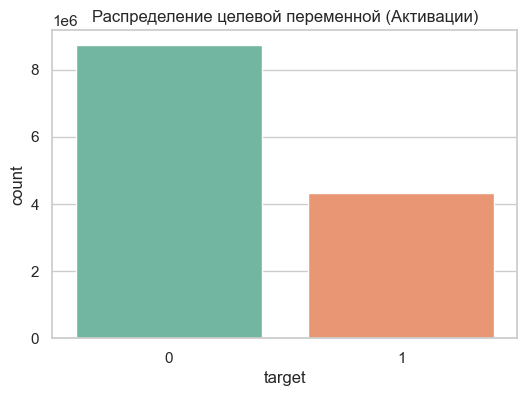

Процент откликов (Конверсия): 33.07207962754974 %


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x='target', palette='Set2')
plt.title('Распределение целевой переменной')
plt.show()

print("Процент откликов:", df_final['target'].mean() * 100, "%")

/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/737194289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='age_bucket', y='target', ax=axes[0], palette='viridis')
/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/737194289.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='gender_cd', y='target', ax=axes[1], palette='pastel')


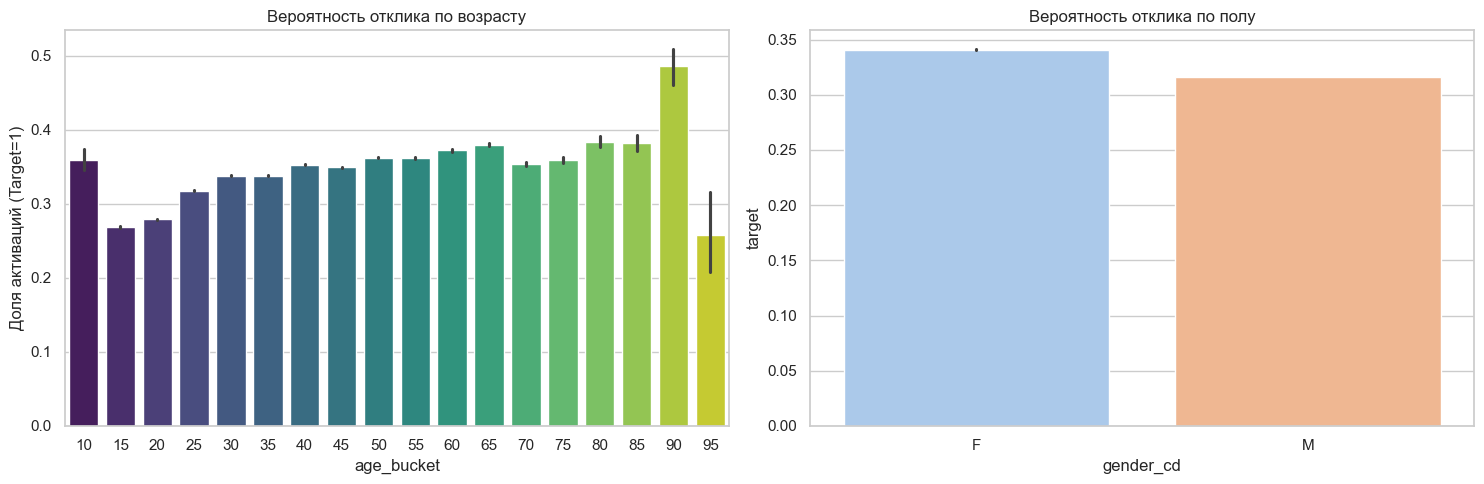

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#Возраст
sns.barplot(data=df_final, x='age_bucket', y='target', ax=axes[0], palette='viridis')
axes[0].set_title('Вероятность отклика по возрасту')
axes[0].set_ylabel('Доля активаций (Target=1)')

#Пол
sns.barplot(data=df_final, x='gender_cd', y='target', ax=axes[1], palette='pastel')
axes[1].set_title('Вероятность отклика по полу')

plt.tight_layout()
plt.show()

/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/3167773435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='target', y='tx_total_count', ax=axes[0], palette='Set1')


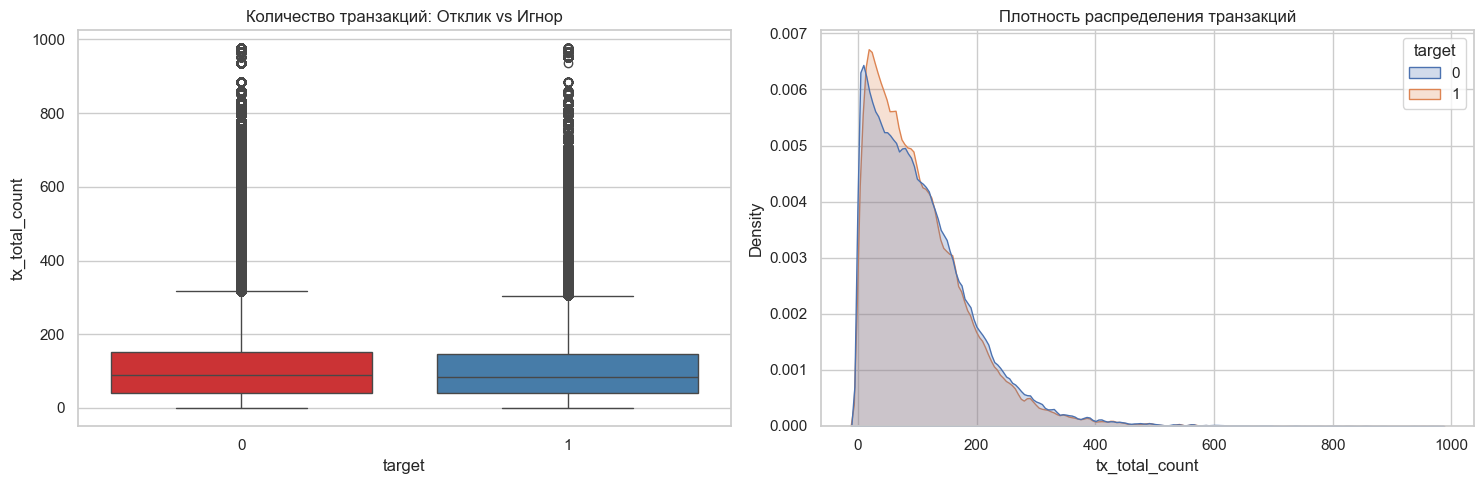

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_filtered = df_final[df_final['tx_total_count'] < 1000]

# Медиана и разброс
sns.boxplot(data=df_filtered, x='target', y='tx_total_count', ax=axes[0], palette='Set1')
axes[0].set_title('Количество транзакций: Отклик vs Игнор')

# Плотность
sns.kdeplot(data=df_filtered, x='tx_total_count', hue='target', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Плотность распределения транзакций')

plt.tight_layout()
plt.show()

/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/2058375871.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='has_past_rewards', y='target', palette='coolwarm')


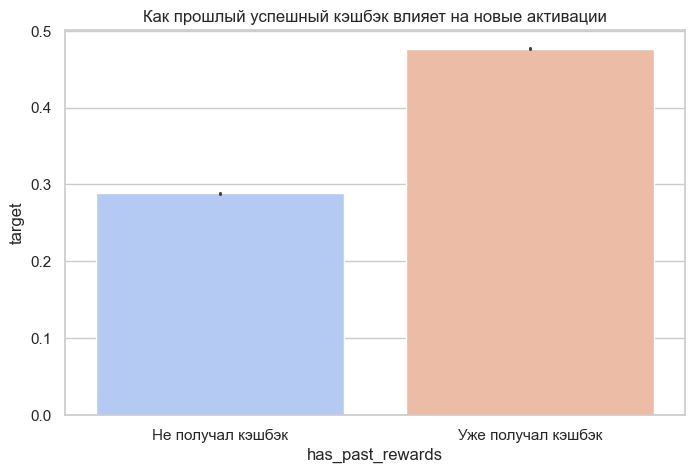

In [ ]:
plt.figure(figsize=(8, 5))
df_final['has_past_rewards'] = (df_final['rewards_count'] > 0).astype(int)

sns.barplot(data=df_final, x='has_past_rewards', y='target', palette='coolwarm')
plt.title('Как прошлый успешный кэшбэк влияет на новые активации')
plt.xticks([0, 1], ['Не получал кэшбэк', 'Уже получал кэшбэк'])
plt.show()

In [ ]:
cross_tab = pd.crosstab(df_final['is_existing_client'], df_final['target'], normalize='index') * 100
print("Конверсия старых и новых клиентов:\n", cross_tab)

Конверсия старых vs новых клиентов:
 target                      0          1
is_existing_client                      
0                   66.783091  33.216909
1                   74.064675  25.935325


/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_48892/2817954873.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


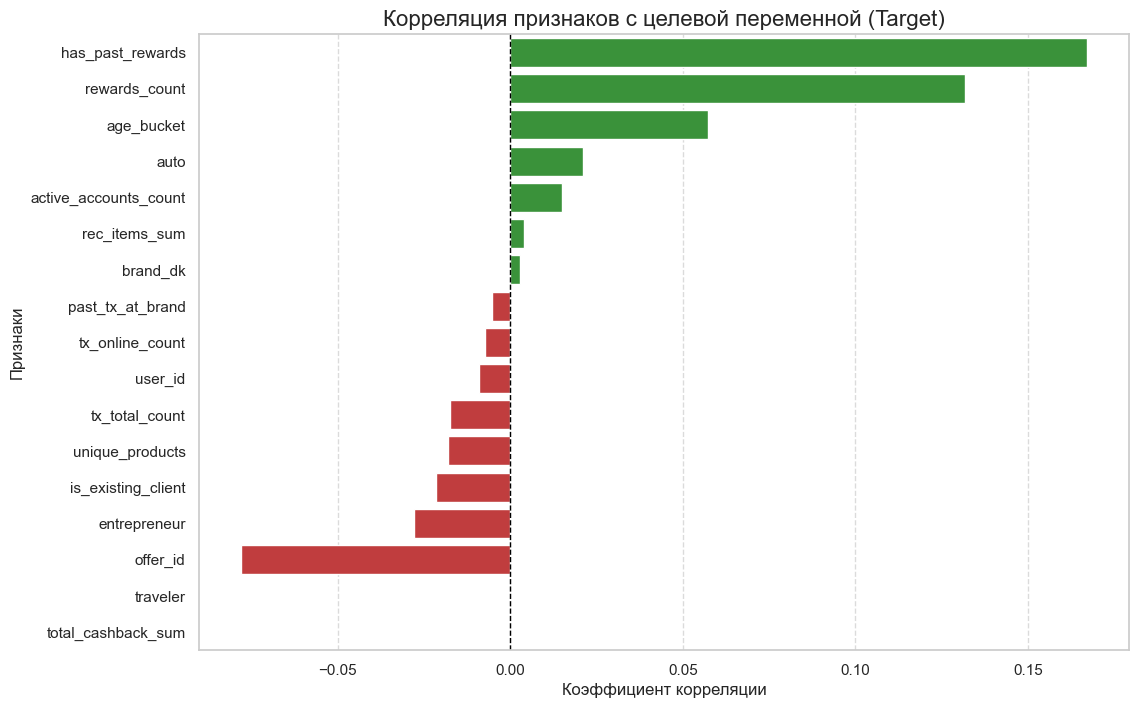

Топ положительных фичей:
has_past_rewards         0.166996
rewards_count            0.131638
age_bucket               0.057339
auto                     0.020911
active_accounts_count    0.015007
Name: target, dtype: float64

Топ отрицательных фичей:
is_existing_client   -0.021609
entrepreneur         -0.027841
offer_id             -0.078029
traveler                   NaN
total_cashback_sum         NaN
Name: target, dtype: float64


In [ ]:
numeric_df = df_final.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])

correlation_matrix = numeric_df.corr()

target_corr = correlation_matrix['target'].drop('target').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#2ca02c' if x > 0 else '#d62728' for x in target_corr.values]

sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

plt.title('Корреляция признаков с целевой переменной', fontsize=16)
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print("Топ положительных фичей:")
print(target_corr.head(5))
print("\nТоп отрицательных фичей:")
print(target_corr.tail(5))

In [6]:
df_final.head()

,user_id,offer_id,target,brand_dk,age_bucket,gender_cd,region,last_activity_day,segment,region_size,auto,traveler,entrepreneur,vip_status,active_accounts_count,unique_products,total_cashback_sum,rewards_count,tx_total_count,tx_online_count,rec_items_sum,past_tx_at_brand,is_existing_client
0,76429,961,0,412734.0,15,F,NaN,2026-02-10,t_10 (40),town,0.0,0.0,0.0,not_vip,7.0,3.0,0.0,0.0,160.0,6.0,166.00,0.0,0
1,56744,128,0,399354.0,55,M,МОСКОВСКАЯ ОБЛ,2026-02-10,t_07 (29),town,0.0,0.0,0.0,not_vip,7.0,5.0,0.0,0.0,136.0,13.0,0.00,0.0,0
2,52364,486,0,411399.0,50,F,NaN,2026-02-10,m_05 (11),msk,0.0,0.0,1.0,UPPERMASS,5.0,4.0,0.0,1.0,123.0,2.0,91.79,0.0,0
3,54576,486,0,411399.0,40,F,ВЛАДИМИРСКАЯ ОБЛ,2026-02-10,m_06 (15),msk,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,389.0,88.0,261.46,0.0,0
4,68899,961,1,412734.0,20,F,КРАСНОДАРСКИЙ КРАЙ,2026-02-10,u_11 (37),urban,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,413.0,62.0,70.00,0.0,0


/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_52591/4022725456.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='region_size', y='target', ax=axes[0], order=order_region, palette='viridis')
/var/folders/s4/jf02s8p97fgfh7l8bhrjd4fr0000gn/T/ipykernel_52591/4022725456.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='vip_status', y='target', ax=axes[1], order=order_vip, palette='magma')


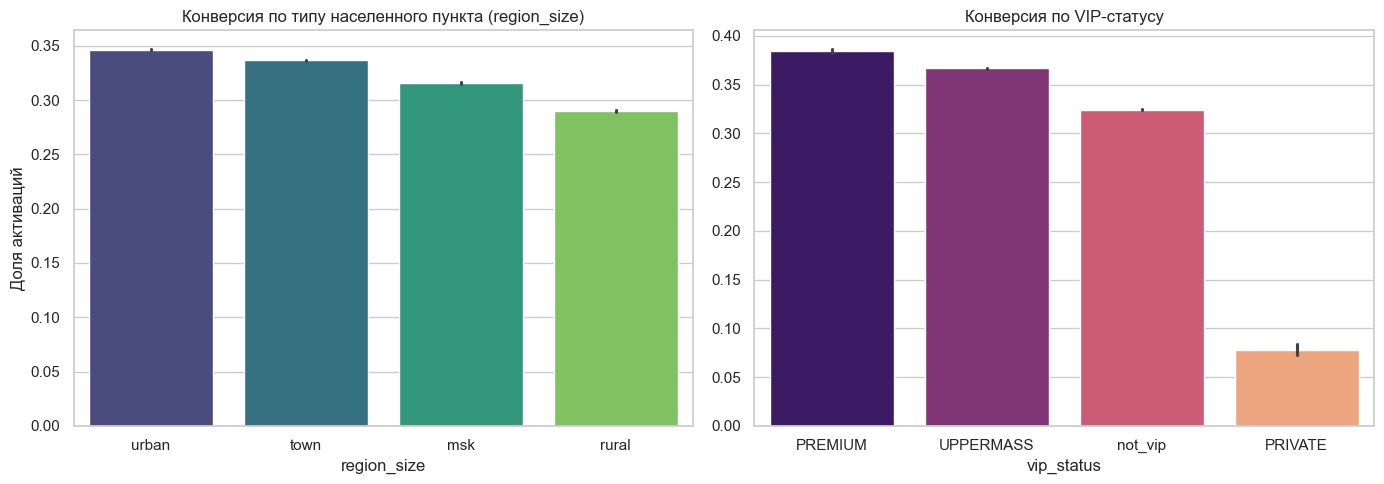

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_region = df_final.groupby('region_size')['target'].mean().sort_values(ascending=False).index
sns.barplot(data=df_final, x='region_size', y='target', ax=axes[0], order=order_region, palette='viridis')
axes[0].set_title('Конверсия по типу населенного пункта (region_size)')
axes[0].set_ylabel('Доля активаций')

# VIP статус
order_vip = df_final.groupby('vip_status')['target'].mean().sort_values(ascending=False).index
sns.barplot(data=df_final, x='vip_status', y='target', ax=axes[1], order=order_vip, palette='magma')
axes[1].set_title('Конверсия по VIPстатусу')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
# переводим сумммы из промежутков в среднии по промежутку числа 
def map_buckets(val):
    if pd.isna(val): return 0
    v = str(val).lower()
    if '10k+' in v or '10000+' in v: return 15000
    if '5k-10k' in v or '5000-10000' in v: return 7500
    if '1k-5k' in v or '1000-5000' in v: return 3000
    if '500-1000' in v: return 750
    if '100-500' in v: return 300
    if '0-100' in v or '<100' in v: return 50
    if '<1k' in v: return 500
    return 0

tx['amount_num'] = tx['amount_bucket'].apply(map_buckets)
tx_new_feats = tx.groupby('user_id').agg(
    tx_sum_total=('amount_num', 'sum'),
    tx_sum_mean=('amount_num', 'mean')
).reset_index()

receipts['items_cost_num'] = receipts['items_cost'].apply(map_buckets)
receipts['items_count'] = pd.to_numeric(receipts['items_count'], errors='coerce').fillna(0)

rec_new_feats = receipts.groupby('user_id').agg(
    items_count_sum=('items_count', 'sum'),
    items_count_mean=('items_count', 'mean'),
    items_cost_sum=('items_cost_num', 'sum'),
    items_cost_mean=('items_cost_num', 'mean'),
    rec_unique_categories=('category_name', 'nunique')
).reset_index()

new_num_cols = ['tx_sum_total', 'tx_sum_mean', 'items_count_sum', 'items_count_mean', 'items_cost_sum', 'items_cost_mean', 'rec_unique_categories']

cols_to_drop = [c for c in new_num_cols if c in df_final.columns]
if cols_to_drop:
    df_final = df_final.drop(columns=cols_to_drop)

df_final = df_final.merge(tx_new_feats, on='user_id', how='left')
df_final = df_final.merge(rec_new_feats, on='user_id', how='left')

df_final[new_num_cols] = df_final[new_num_cols].fillna(0)



if 'start_date' not in df_final.columns:
    seens_dates = seens[['user_id', 'offer_id', 'start_date']].drop_duplicates()
    df_final = df_final.merge(seens_dates, on=['user_id', 'offer_id'], how='left')

df_final['start_date'] = pd.to_datetime(df_final['start_date'], errors='coerce')
df_final['last_activity_day'] = pd.to_datetime(df_final['last_activity_day'], errors='coerce')

df_final['recency_days'] = (df_final['last_activity_day'] - df_final['start_date']).dt.days.abs()
df_final['recency_days'] = df_final['recency_days'].fillna(999) # Если активности не было ставим 999


df_final['hunter_index'] = df_final['rewards_count'] / (df_final['tx_total_count'] + 1)
df_final['online_share'] = df_final['tx_online_count'] / (df_final['tx_total_count'] + 1e-9)

if 'past_tx_at_brand' in df_final.columns:
    df_final['brand_affinity'] = df_final['past_tx_at_brand'] / (df_final['tx_total_count'] + 1)


In [19]:
df_final.head()

,user_id,offer_id,target,brand_dk,age_bucket,gender_cd,region,last_activity_day,segment,region_size,auto,traveler,entrepreneur,vip_status,active_accounts_count,unique_products,total_cashback_sum,rewards_count,tx_total_count,tx_online_count,rec_items_sum,past_tx_at_brand,is_existing_client,tx_sum_total,tx_sum_mean,items_count_sum,items_count_mean,items_cost_sum,items_cost_mean,rec_unique_categories,start_date,recency_days,hunter_index,online_share,brand_affinity
0,76429,961,0,412734.0,15,F,NaN,2026-02-10,t_10 (40),town,0.0,0.0,0.0,not_vip,7.0,3.0,0.0,0.0,160.0,6.0,166.00,0.0,0,2400000.0,15000.0,166.00,2.634921,10400.0,165.079365,28.0,2025-06-03,252,0.000000,0.037500,0.0
1,56744,128,0,399354.0,55,M,МОСКОВСКАЯ ОБЛ,2026-02-10,t_07 (29),town,0.0,0.0,0.0,not_vip,7.0,5.0,0.0,0.0,136.0,13.0,0.00,0.0,0,2040000.0,15000.0,0.00,0.000000,0.0,0.000000,0.0,2025-06-03,252,0.000000,0.095588,0.0
2,52364,486,0,411399.0,50,F,NaN,2026-02-10,m_05 (11),msk,0.0,0.0,1.0,UPPERMASS,5.0,4.0,0.0,1.0,123.0,2.0,91.79,0.0,0,1845000.0,15000.0,91.79,1.176795,32050.0,410.897436,46.0,2025-06-03,252,0.008065,0.016260,0.0
3,54576,486,0,411399.0,40,F,ВЛАДИМИРСКАЯ ОБЛ,2026-02-10,m_06 (15),msk,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,389.0,88.0,261.46,0.0,0,5835000.0,15000.0,261.46,1.233302,32950.0,155.424528,71.0,2025-06-03,252,0.000000,0.226221,0.0
4,68899,961,1,412734.0,20,F,КРАСНОДАРСКИЙ КРАЙ,2026-02-10,u_11 (37),urban,0.0,0.0,0.0,not_vip,7.0,6.0,0.0,0.0,413.0,62.0,70.00,0.0,0,6195000.0,15000.0,70.00,1.458333,7900.0,164.583333,24.0,2025-06-03,252,0.000000,0.150121,0.0


In [ ]:

iqr_cols = [
    'tx_total_count', 
    'tx_sum_total', 
    'tx_sum_mean', 
    'items_count_sum', 
    'items_cost_sum'
]

for col in iqr_cols:
    if col in df_final.columns:
        q1 = df_final[col].quantile(0.25)
        q3 = df_final[col].quantile(0.75)
        
        iqr = q3 - q1
        
        upper_bound = q3 + 3 * iqr
        
        df_final[col] = df_final[col].clip(upper=upper_bound)
        

✂️ Начинаем очистку методом 3 IQR...
✔️ tx_total_count: верхняя граница установлена на 480.00
✔️ tx_sum_total: верхняя граница установлена на 7200000.00
✔️ tx_sum_mean: верхняя граница установлена на 15000.00
✔️ items_count_sum: верхняя граница установлена на 404.00
✔️ items_cost_sum: верхняя граница установлена на 55800.00
✅ Хвосты обрезаны по правилу 3 IQR!


🧠 Обучаем CatBoost...
0:	test: 0.5983954	best: 0.5983954 (0)	total: 222ms	remaining: 1m 6s
50:	test: 0.6513947	best: 0.6513947 (50)	total: 5.3s	remaining: 25.9s
100:	test: 0.6636398	best: 0.6636398 (100)	total: 18.5s	remaining: 36.5s
150:	test: 0.6699267	best: 0.6699267 (150)	total: 28.9s	remaining: 28.6s
200:	test: 0.6729876	best: 0.6730059 (198)	total: 39.1s	remaining: 19.2s
250:	test: 0.6746199	best: 0.6746199 (250)	total: 47.2s	remaining: 9.2s
299:	test: 0.6757809	best: 0.6757809 (299)	total: 57.1s	remaining: 0us

bestTest = 0.6757809106
bestIteration = 299


📊 Считаем SHAP...


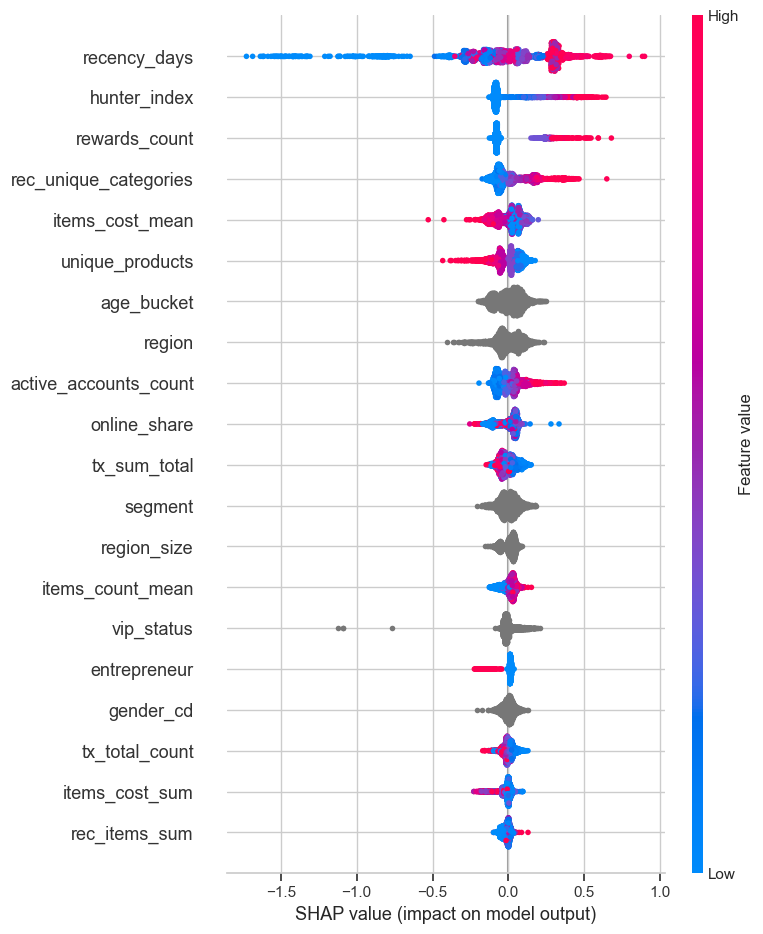

In [ ]:
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

# для скорости берем сэмпл
df_sample = df_final.sample(n=200000, random_state=42).copy()

drop_cols = [
    'user_id', 'offer_id', 'target', 'brand_dk', 
    'last_activity_day', 'start_date', 'end_date', 'offer_text'
]
drop_cols = [c for c in drop_cols if c in df_sample.columns]

features = [c for c in df_sample.columns if c not in drop_cols]

cat_features = ['age_bucket', 'gender_cd', 'region', 'segment', 'region_size', 'vip_status', 'offer_category']
cat_features = [c for c in cat_features if c in df_sample.columns]

df_sample[cat_features] = df_sample[cat_features].fillna('Unknown').astype(str)

num_features = [c for c in features if c not in cat_features]
df_sample[num_features] = df_sample[num_features].fillna(0).astype(float)

X = df_sample[features]
y = df_sample['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(
    iterations=300, 
    learning_rate=0.1, 
    cat_features=cat_features,
    verbose=50,
    eval_metric='AUC'
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:3000])

shap.summary_plot(shap_values, X_test[:3000])